In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const
from tqdm import tqdm

In [2]:
import scienceplots
plt.style.use(['science', 'no-latex'])

In [3]:
two_dim = False
inputname = '../runs/29_9/H_input_2025-09-29_11-50-12.txt'
outputname=inputname.replace('input', 'output')
logname=inputname.replace('input', 'log')
orbit_plot = True
input_plot = False #if True plots the initial distribution from the input
density_plot = False

In [4]:
def input_opening(inputname = ''):
    inputf = open(inputname, 'r')

    N = int(inputf.readline())
    n_dim = int(inputf.readline())
        
    t_0 = float(inputf.readline())

    mass_0 = []
    for i in range(3, N+3):
        mass_0.append(float(inputf.readline()))
        
    mass_0 = np.array(mass_0)
    
    #the initial positions are arranged in an array where the first index gives the particle 
    #and the second gives the direction
    position_0 = []
    for i in range(N+4, 2*N + 4):
        position_0.append((inputf.readline()).rstrip())
        
    position_0 = [p.split() for p in position_0]

    for i in range(N):
        for j in range(n_dim):
            position_0[i][j] = float(position_0[i][j])
            
    position_0 = np.array(position_0)

    #the initial velocities are arranged just like the positions
    velocity_0 = []
    for i in range(2*N + 5, 3*N + 5):
        velocity_0.append((inputf.readline()).rstrip())
        
    velocity_0 = [v.split() for v in velocity_0]

    for i in range(N):
        for j in range(n_dim):
            velocity_0[i][j] = float(velocity_0[i][j])
            
    velocity_0 = np.array(velocity_0)
    inputf.close() 
    
    return N, t_0, mass_0, position_0, velocity_0

In [5]:
import os
cores = os.cpu_count()
print(f"You have {cores} CPU cores.")

You have 20 CPU cores.


In [6]:
from concurrent.futures import ProcessPoolExecutor

def parse_snapshot_at_offset(filename, offset):
    """
    Parse a single snapshot starting at file byte offset.
    Returns a dict with parsed data.
    """
    with open(filename, 'r') as f:
        f.seek(offset)
        
        N = int(f.readline().strip())
        D = int(f.readline().strip())
        t = float(f.readline().strip())
        
        # Skip masses
        for _ in range(N):
            f.readline()
        
        positions = [list(map(float, f.readline().strip().split())) for _ in range(N)]
        velocities = [list(map(float, f.readline().strip().split())) for _ in range(N)]
        
        return {
            'N': N,
            'D': D,
            'time': t,
            'positions': np.array(positions),
            'velocities': np.array(velocities)
        }

def find_snapshot_offsets(filename):
    """
    Scan the file once to find byte offsets where each snapshot starts.
    """
    offsets = []
    with open(filename, 'r') as f:
        while True:
            pos = f.tell()
            line = f.readline()
            if not line:
                break
            # If line looks like a snapshot start (N)
            if line.strip().isdigit():
                offsets.append(pos)
                # Skip N, D, time, masses, positions, velocities to get to next snapshot
                N = int(line.strip())
                D = int(f.readline().strip())
                # 1 line for time + N for masses + N for positions + N for velocities
                to_skip = 1 + N*3
                for _ in range(to_skip):
                    f.readline()
            else:
                # If format guarantees snapshot starts with N, else ignore line
                continue
    return offsets

def parallel_parse(filename, max_workers=4):
    offsets = find_snapshot_offsets(filename)
    print(f"Found {len(offsets)} snapshots.")

    results = []
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(parse_snapshot_at_offset, filename, off) for off in offsets]
        for future in futures:
            results.append(future.result())

    # Check consistency
    N = results[0]['N']
    D = results[0]['D']

    times = np.array([r['time'] for r in results])
    positions = np.array([r['positions'] for r in results])  # (snapshots, N, D)
    velocities = np.array([r['velocities'] for r in results])  # (snapshots, N, D)

    # Transpose to (N, snapshots, D)
    positions = positions.transpose(1, 0, 2)
    velocities = velocities.transpose(1, 0, 2)

    return N, D, len(results), times, positions, velocities

In [7]:
n_particles, init_t, mass, init_p, init_v = input_opening(inputname)

if input_plot:
    fig = plt.figure()
    if (two_dim == True):
        ax = fig.add_subplot()
        for i in range(n_particles): ax.scatter(init_p[i][0], init_p[i][1], color = 'b')
        ax.set(xlabel = 'x', ylabel = 'y', title = str(n_particles) + ' particles')
    else:
        ax = fig.add_subplot(projection='3d')
        for i in range(n_particles): ax.scatter(init_p[i][0], init_p[i][1], init_p[i][2], color = 'b', s = 1)
        ax.set(xlabel = 'x', ylabel = 'y', zlabel = 'z', title = str(n_particles) + ' particles')

    plt.show()

In [8]:
# Usage example
if __name__ == '__main__':
    filename = outputname
    N, n_dim, snap_number, time, positions, velocities = parallel_parse(filename, max_workers=cores-2)


Found 219 snapshots.


In [9]:
print(f"Loaded {snap_number} snapshots with {N} particles and {n_dim} dimensions.")

Loaded 219 snapshots with 5000 particles and 3 dimensions.


### Computing radial quantities

In [10]:
radius = []
for i in range(n_particles): radius.append(np.sqrt(positions[i, :, 0]**2 + positions[i, :, 1]**2 + positions[i, :, 2]**2))
radius = np.array(radius)

radius_at_t = []
for i in range(len(time)): radius_at_t.append(np.sqrt(positions[:, i, 0]**2 + positions[:, i, 1]**2 + positions[:, i, 2]**2))
radius_at_t = np.array(radius_at_t)

In [11]:
radial_v = []
for i in range(n_particles): radial_v.append((positions[i, :, 0]*velocities[i, :, 0] + positions[i, :, 1]*velocities[i, :, 1] + positions[i, :, 2]*velocities[i, :, 2])/radius[i, :])
radial_v = np.array(radial_v)

### IU-> PU

In [12]:
#conversioni
MSOL_PER_IU = 1E10
KPC_PER_IU = 1.0
KMS_PER_IU = 207.38652969844208
MYR_PER_IU = 4.714829951118732  
#softening usato nel treecode
soft_pair = 0.06 # kpc

### System Energy

In [13]:
#Get the total energies from the log file, in the CM frame
def GetEnergy(filename, N):
    file_output = open(filename, "r")
    output = np.array(file_output.read().splitlines())
    
    idx = np.where(output == output[9])[0] #Find the row with T and U

    E = []
    K = []
    U = []
    t = []
    
    for i in idx:
        t.append(float(output[i+1].split()[0]))
        E.append(float(output[i + 1].split()[1]))
        K.append(float(output[i + 1].split()[2]))
        U.append(-float(output[i + 1].split()[3]))
        
    #K = (np.array(K) - K_CM) * M_sun / v_iu_cgs**2
    #U = np.array(U) * G_p * 
    #E = np.add(K, U)

    file_output.close()
    return np.array(t), np.array(E), np.array(K), np.array(U)

In [14]:
time_E, E, K, U = GetEnergy(logname, n_particles)

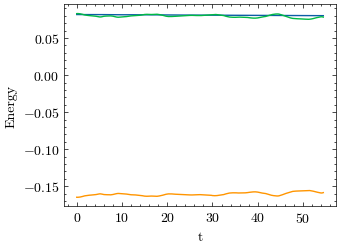

In [15]:
    #----------Plot of the energy----------

plt.plot(time_E, E, label="Total energy")
plt.plot(time_E, K, label="Total kinetic energy")
plt.plot(time_E, U, label="Total potential energy")
plt.xlabel("t")
plt.ylabel("Energy")
plt.show()

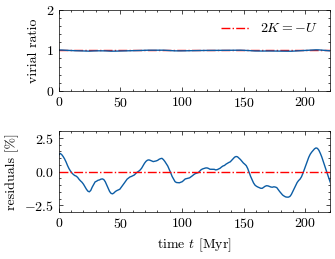

In [31]:
virial_ratio = []
for t in range(len(time_E)):
    virial_ratio.append(2 * K[t] / ( - U[t]))

fig, ax = plt.subplots(nrows= 2)
virial_ratio = np.array(virial_ratio)
ax[0].axhline(1.0, color = 'r', ls='-.',label = r'$2K = -U$')
ax[0].plot(time_E * MYR_PER_IU, virial_ratio)
ax[0].set_ylabel('virial ratio')
ax[0].set_ylim(0, 2)
ax[0].set_xlim(0, 220)
ax[0].legend()

residuals =  (virial_ratio - 1) / virial_ratio

ax[1].plot(time_E * MYR_PER_IU, residuals * 100)
ax[1].set_xlim(0, 220)
ax[1].set_ylim(-3, 3)
ax[1].set_ylabel('residuals [%]')
ax[1].set_xlabel(r'time $t$ [Myr]')
ax[1].axhline(0, c = 'r', ls = '-.', )

plt.subplots_adjust(hspace=0.5)
#plt.savefig('../plots/virial_ratio.svg')
plt.show()

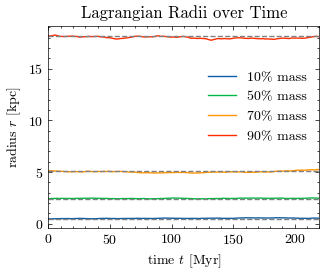

In [64]:
#compute Lagrangian radii enclosing specified mass fractions
def lagrangian_radii(r, mass_fractions=[0.1, 0.5, 0.7, 0.9]):
    percentiles = np.array(mass_fractions) * 100
    return np.percentile(r, percentiles)

#lagrangian Radii over time
r_lag_all = []
for snap in range(snap_number):
    r_lag = lagrangian_radii(radius[:, snap])
    r_lag_all.append(r_lag)

r_lag_all = np.array(r_lag_all)

fractions = [10, 50, 70, 90]

# --- Plot 1: Raggi Lagrangiani ---
for i, frac in enumerate(fractions):
    plt.plot(time * MYR_PER_IU, r_lag_all[:, i], label=f"{frac}% mass")
    plt.axhline(r_lag_all[0, i], color='gray', linestyle='--', linewidth=1)

plt.ylabel(r"radius $r$ [kpc]")
plt.xlabel(r'time $t$ [Myr]')
plt.title("Lagrangian Radii over Time")
plt.xlim(0, 220)
plt.legend(loc = 'best', fontsize=10, bbox_to_anchor=(1, 0.6))

#plt.savefig('../plots/lag_radii.svg')
plt.show()

In [18]:
print(2 * K[0] / np.abs(U[0]))

1.007527926177756


In [19]:
print(r_lag_all.shape)

(219, 4)


## Check if density is Hernquist